# Proiect PCLP3 - Gheorghe Alexandru-Nicolae - 311CB

Pentru inceput am construit un set de date tabelar in care am inclus date importante despre zborurile de pe aeroportul Otopeni din Bucuresti catre toate capitalele europene mari (Londra, Paris, Roma, Barcelona, Amsterdam, Frankfurt, Viena) care decoleaza in perioada 20.06.2026-23.08.2026 (intre sesiunea din sem II si sesiunea de restante). In tabel sunt trecute ora de plecare, orasul de plecare, orasul de sosire, distanta (nr de zile) pana la data plecarii, numarul de escale, durata zborului (in minute), numele companiei si cel mai important, pretul.

In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import seaborn as sns

train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

In [128]:
def adauga_coloana_weekend(df):
    data_baza = datetime(2026, 5, 27)
    este_weekend = []
    for zile in df["zile_pana_la_plecare"]:
        if pd.isna(zile):
            este_weekend.append(0)
            continue
        data_zbor = data_baza + pd.Timedelta(days=int(zile))
        if data_zbor.weekday() in [4, 5, 6]:
            este_weekend.append(1)
        else:
            este_weekend.append(0)
    df["este_weekend"] = este_weekend
    return df

train_df = adauga_coloana_weekend(train_df)
test_df = adauga_coloana_weekend(test_df)

In [129]:
nule_train = train_df.isnull().sum()
existente_train = train_df.count()
procent_train = (train_df.isnull().sum() / len(train_df)) * 100

raport_train = pd.DataFrame({
    'Existente': existente_train,
    'Nule': nule_train,
    'Procent Nule (%)': procent_train
})
display(raport_train)

nule_test = test_df.isnull().sum()
existente_test = test_df.count()
procent_test = (test_df.isnull().sum() / len(test_df)) * 100

raport_test = pd.DataFrame({
    'Existente': existente_test,
    'Nule': nule_test,
    'Procent Nule (%)': procent_test
})
display(raport_test)

,Existente,Nule,Procent Nule (%)
nume_companie,2367,0,0.0
oras_plecare,2367,0,0.0
oras_sosire,2367,0,0.0
ora_plecare,2367,0,0.0
zile_pana_la_plecare,2367,0,0.0
durata_minute,2367,0,0.0
numar_escale,2367,0,0.0
pret_bilet,2367,0,0.0
este_weekend,2367,0,0.0


,Existente,Nule,Procent Nule (%)
nume_companie,790,0,0.0
oras_plecare,790,0,0.0
oras_sosire,790,0,0.0
ora_plecare,790,0,0.0
zile_pana_la_plecare,790,0,0.0
durata_minute,790,0,0.0
numar_escale,790,0,0.0
pret_bilet,790,0,0.0
este_weekend,790,0,0.0


**Ce observam?** Toate coloanele sunt complete. Inseamna ca datele de la API au fost colectate in intregime si toate request-urile au functionat

**Preprocesari necesare:** In cazul in care schimbam data-set-urile avem mai jos codul aferent pentru umplerea coloanelor care au informatii lipsa

In [130]:
train_df['durata_minute'].fillna(train_df['durata_minute'].mean(), inplace=True)
test_df['durata_minute'].fillna(test_df['durata_minute'].mean(), inplace=True)

train_df['pret_bilet'].fillna(train_df['pret_bilet'].mean(), inplace=True)
test_df['pret_bilet'].fillna(test_df['pret_bilet'].mean(), inplace=True)

train_df['zile_pana_la_plecare'].fillna(train_df['zile_pana_la_plecare'].mean(), inplace=True)
test_df['zile_pana_la_plecare'].fillna(test_df['zile_pana_la_plecare'].mean(), inplace=True)

train_df['numar_escale'].fillna(train_df['numar_escale'].mode()[0], inplace=True)
test_df['numar_escale'].fillna(test_df['numar_escale'].mode()[0], inplace=True)

train_df['nume_companie'].fillna(train_df['nume_companie'].mode()[0], inplace=True)
test_df['nume_companie'].fillna(test_df['nume_companie'].mode()[0], inplace=True)

train_df['oras_plecare'].fillna(train_df['oras_plecare'].mode()[0], inplace=True)
test_df['oras_plecare'].fillna(test_df['oras_plecare'].mode()[0], inplace=True)

train_df['oras_sosire'].fillna(train_df['oras_sosire'].mode()[0], inplace=True)
test_df['oras_sosire'].fillna(test_df['oras_sosire'].mode()[0], inplace=True)

train_df['ora_plecare'].fillna(train_df['ora_plecare'].mode()[0], inplace=True)
test_df['ora_plecare'].fillna(test_df['ora_plecare'].mode()[0], inplace=True)

train_df['este_weekend'].fillna(train_df['este_weekend'].mode()[0], inplace=True)
test_df['este_weekend'].fillna(test_df['este_weekend'].mode()[0], inplace=True)

/tmp/ipykernel_1502/623763436.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['durata_minute'].fillna(train_df['durata_minute'].mean(), inplace=True)
/tmp/ipykernel_1502/623763436.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].meth

In [131]:
display(train_df.describe(include='all'))
display(test_df.describe(include='all'))

,nume_companie,oras_plecare,oras_sosire,ora_plecare,zile_pana_la_plecare,durata_minute,numar_escale,pret_bilet,este_weekend
count,2367,2367,2367,2367.000000,2367.000000,2367.000000,2367.000000,2367.000000,2367.000000
unique,8,1,7,NaN,NaN,NaN,NaN,NaN,NaN
top,Wizz Air Malta,OTP,VIE,NaN,NaN,NaN,NaN,NaN,NaN
freq,864,2367,576,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,12.989438,56.452049,188.035488,0.187579,56.483312,0.449514
std,NaN,NaN,NaN,5.221903,18.721999,81.330117,0.390458,31.334607,0.497550
min,NaN,NaN,NaN,6.000000,24.000000,100.000000,0.000000,16.000000,0.000000
25%,NaN,NaN,NaN,8.000000,40.000000,140.000000,0.000000,25.000000,0.000000
50%,NaN,NaN,NaN,13.000000,57.000000,180.000000,0.000000,50.000000,0.000000
75%,NaN,NaN,NaN,18.000000,73.000000,200.000000,0.000000,87.000000,1.000000


,nume_companie,oras_plecare,oras_sosire,ora_plecare,zile_pana_la_plecare,durata_minute,numar_escale,pret_bilet,este_weekend
count,790,790,790,790.000000,790.000000,790.000000,790.000000,790.000000,790.000000
unique,8,1,7,NaN,NaN,NaN,NaN,NaN,NaN
top,Wizz Air Malta,OTP,VIE,NaN,NaN,NaN,NaN,NaN,NaN
freq,281,790,204,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,13.203797,54.916456,185.803797,0.178481,56.230380,0.440506
std,NaN,NaN,NaN,5.081115,19.306168,79.833593,0.383160,31.467207,0.496762
min,NaN,NaN,NaN,6.000000,24.000000,100.000000,0.000000,16.000000,0.000000
25%,NaN,NaN,NaN,9.000000,37.250000,105.000000,0.000000,24.000000,0.000000
50%,NaN,NaN,NaN,13.000000,54.000000,160.000000,0.000000,50.000000,0.000000
75%,NaN,NaN,NaN,18.000000,72.000000,200.000000,0.000000,87.000000,1.000000


**Ce observam?** `describe()` ne da un rezumat rapid al fiecarei coloane: cate valori are, care e minimul si maximul, media, si percentilele 25/50/75. De exemplu, din coloana `pret_bilet` putem vedea care e cel mai ieftin si cel mai scump bilet din dataset.

**Suspiciuni/idei:** Daca minimul pentru `pret_bilet` e ceva ridicol de mic (ex: 1 EUR) sau maximul e imens (ex: 5000 EUR), probabil sunt erori in date sau niste outlieri foarte extremi pe care ar trebui sa ii investigam. De asemenea, daca `zile_pana_la_plecare` are valori negative, inseamna ca ceva a mers prost la calcul.

**Preprocesari necesare:** Dupa ce vedem valorile extreme, decidem daca le lasam sau le scoatem. Deocamdata le lasam si vedem cum influenteaza modelul.

In [132]:
hist_train_df = train_df.copy()
hist_test_df = test_df.copy()

hist_train_df.drop(columns='nume_companie', inplace=True)
hist_test_df.drop(columns='nume_companie', inplace=True)
hist_train_df.drop(columns='oras_plecare', inplace=True)
hist_test_df.drop(columns='oras_plecare', inplace=True)
hist_train_df.drop(columns='oras_sosire', inplace=True)
hist_test_df.drop(columns='oras_sosire', inplace=True)

countplot_train = hist_train_df.copy()
countplot_test = hist_test_df.copy()

hist_train_df.drop(columns='numar_escale', inplace=True)
hist_test_df.drop(columns='numar_escale', inplace=True)
hist_train_df.drop(columns='este_weekend', inplace=True)
hist_test_df.drop(columns='este_weekend', inplace=True)

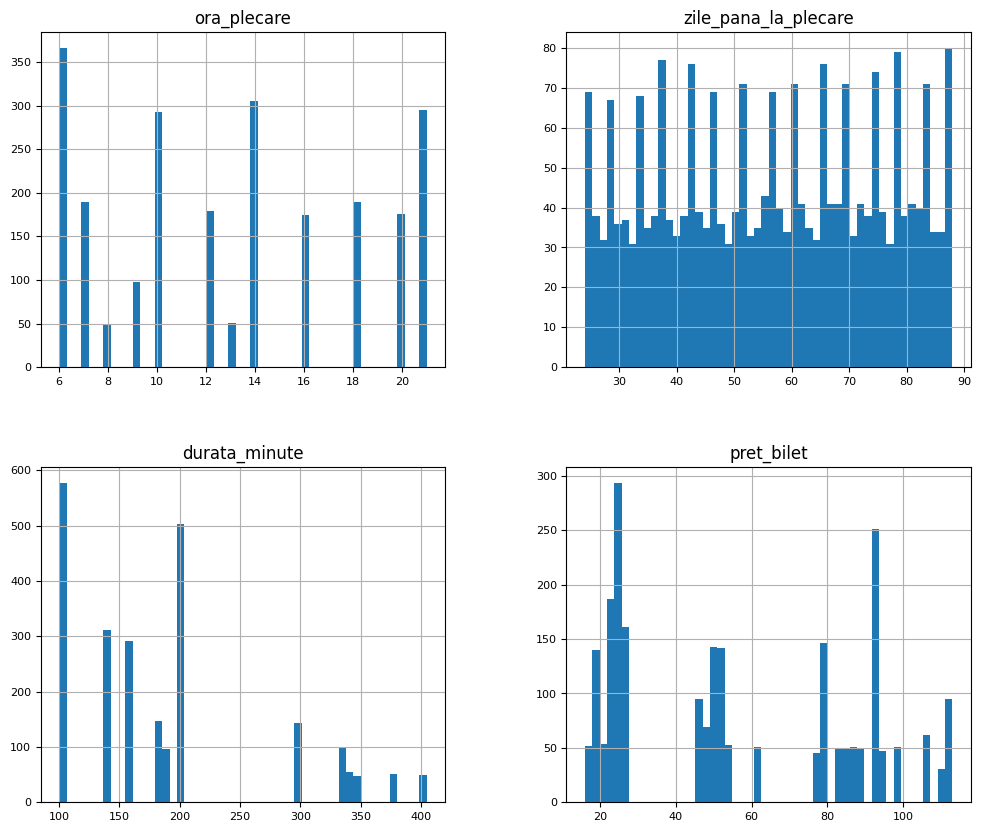

In [133]:
hist_train_df.hist(figsize=(12, 10), bins=50, xlabelsize=8, ylabelsize=8)
plt.show()

**Ce observam?** Histogramele arata cat de des apare fiecare valoare pentru fiecare coloana numerica. De exemplu, la `pret_bilet` vedem probabil ca majoritatea biletelor sunt ieftine (bara mare la stanga) si doar putine sunt foarte scumpe (bare mici spre dreapta). La `durata_minute` vedem probabil mai multe varfuri, cate unul pentru fiecare destinatie - Viena e mai aproape, Londra mai departe.

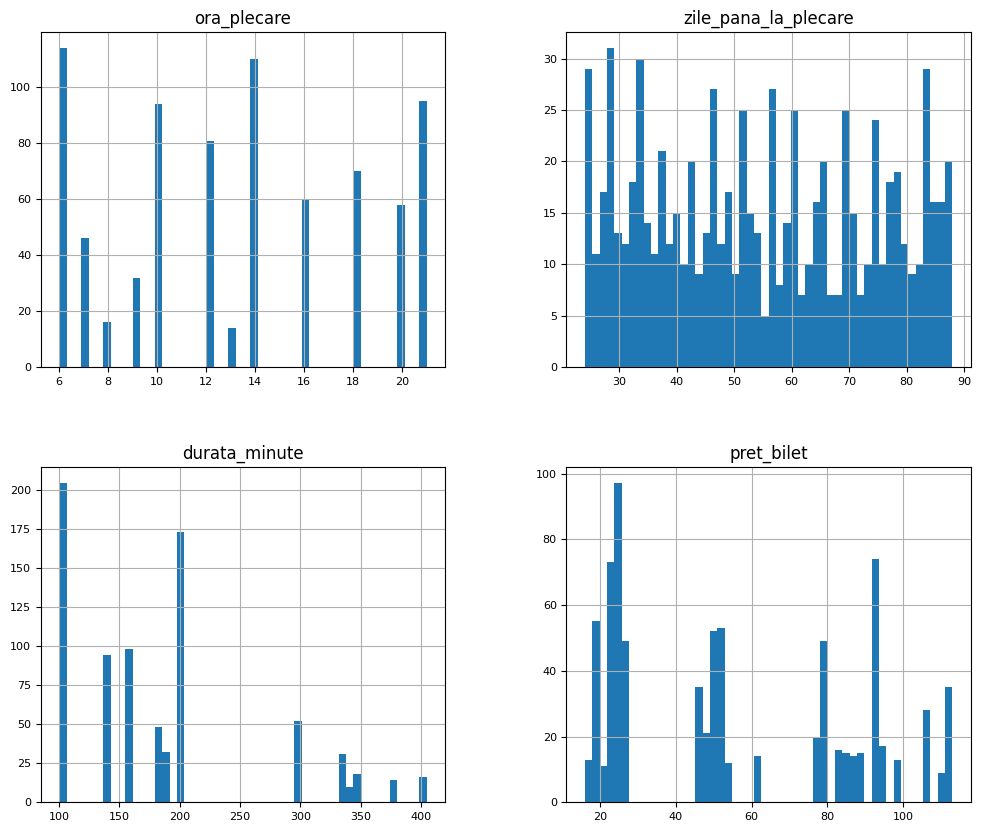

In [134]:
hist_test_df.hist(figsize=(12, 10), bins=50, xlabelsize=8, ylabelsize=8)
plt.show()

**Ce observam?** Histogramele din setul de test ar trebui sa arate cam la fel ca cele din train. Asta e important: daca formele sunt similare, inseamna ca atunci cand am impartit datele in train/test, am amestecat bine si nu au nimerit toate datele "ciudate" intr-un singur set.

**Suspiciuni/idei:** Daca o histograma arata complet diferit fata de cea din train (de exemplu, in test avem doar bilete scumpe), inseamna ca impartirea train/test a mers prost si trebuie refacuta.

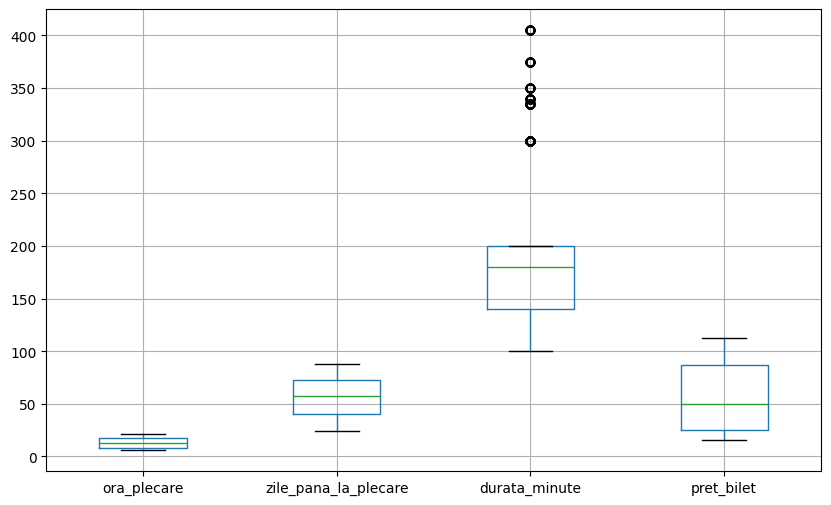

In [135]:
plt.figure(figsize=(10, 6))
hist_train_df.boxplot()
plt.show()

**Ce observam?** Boxplot-ul arata pentru fiecare coloana: unde e mediana (linia din mijlocul cutiei), unde sunt 50% din valori (cutia in sine), si ce valori sunt considerate outlieri (punctele de deasupra si de sub "mustati"). Punctele izolate de deasupra cutiei sunt valorile extreme. Cele mai multe puncte izolate sunt pentru durata_minute(normal peentru zboruri cu escala)


**Preprocesari necesare:** Outlierii nu inseamna neaparat date gresite - un bilet de 800 EUR spre Londra e real. Trebuie sa ne uitam la ei si sa decidem daca ii pastram. Daca sunt erori clare (ex: durata de 10000 minute), ii eliminam.

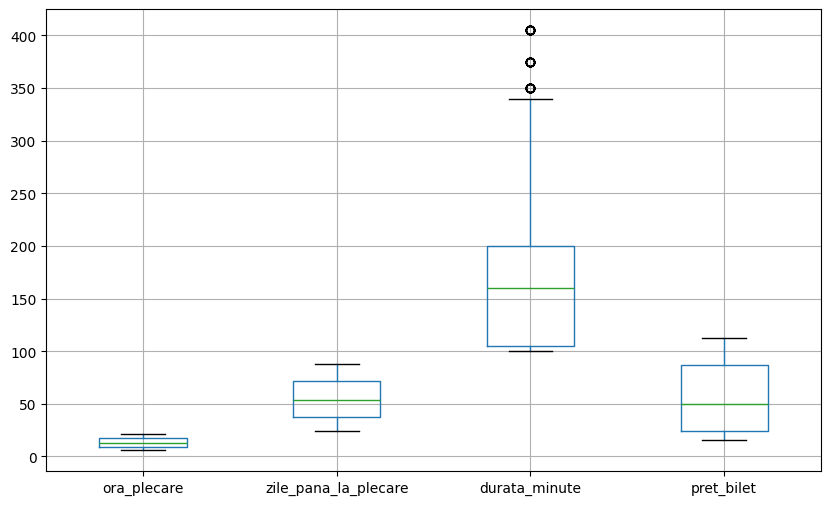

In [136]:
plt.figure(figsize=(10, 6))
hist_test_df.boxplot()
plt.show()

**Ce observam?** Acelasi tip de grafic dar pentru setul de test. Comparam vizual cu boxplot-ul din train sa vedem daca outlierii sunt similari ca numar si marime.

**Suspiciuni/idei:** Daca in test apar outlieri mult mai mari decat in train, modelul nu a "vazut" exemple similare la antrenare si va face predictii proaste pentru ele. E ca si cum ai invata pentru un examen cu un manual, dar la examen apar intrebari dintr-un alt manual.

**Preprocesari necesare:** Aceleasi ca la train.

/tmp/ipykernel_1502/1430280179.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x='este_weekend', palette='Set2')


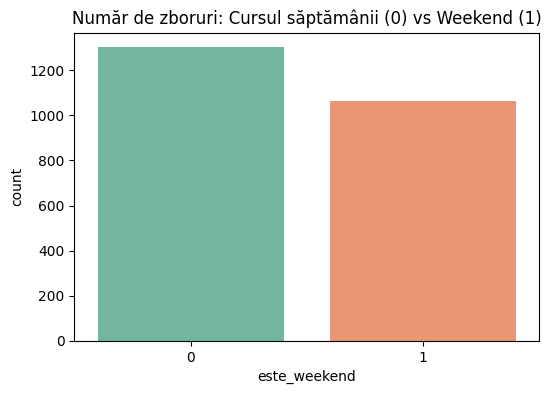

/tmp/ipykernel_1502/1430280179.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x='numar_escale', palette='Pastel1')


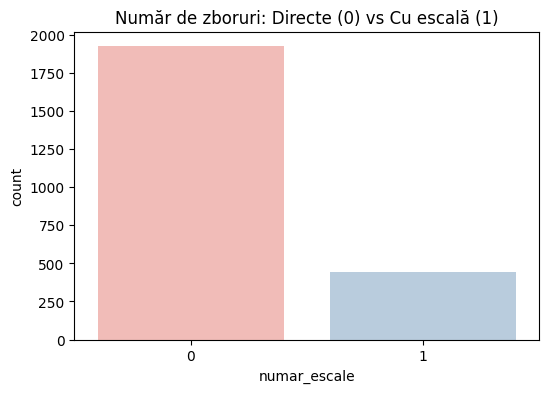

In [137]:
countplot_train.drop(columns='pret_bilet', inplace=True)
countplot_test.drop(columns='pret_bilet', inplace=True)
countplot_train.drop(columns='durata_minute', inplace=True)
countplot_test.drop(columns='durata_minute', inplace=True)
countplot_train.drop(columns='zile_pana_la_plecare', inplace=True)
countplot_test.drop(columns='zile_pana_la_plecare', inplace=True)
countplot_train.drop(columns='ora_plecare', inplace=True)
countplot_test.drop(columns='ora_plecare', inplace=True)

plt.figure(figsize=(6, 4))
sns.countplot(data=train_df, x='este_weekend', palette='Set2')
plt.title('Numar de zboruri: Cursul saptamanii (0) vs Weekend (1)')
plt.show()

plt.figure(figsize=(6, 4))
sns.countplot(data=train_df, x='numar_escale', palette='Pastel1')
plt.title('Numar de zboruri: Directe (0) vs Cu escala (1)')
plt.show()

**Ce observam?** Countplot-ul numara de cate ori apare fiecare valoare pentru coloanele discrete ramase: `numar_escale` si `este_weekend`.

**Suspiciuni/idei:** Daca avem 1000 de zboruri directe si doar 20 cu escale, modelul va invata mult mai bine cum sa prezica pretul zborurilor directe. Pentru cele cu escale, predictiile vor fi mai nesigure pur si simplu pentru ca are putine exemple de la care sa invete.

**Preprocesari necesare:** Daca dezechilibrul e foarte mare, putem incerca sa colectam mai multe date cu escale sau sa indicam modelului sa acorde mai multa atentie acestor cazuri rare.

/tmp/ipykernel_1502/2179889333.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=test_df, x='este_weekend', palette='Set2')


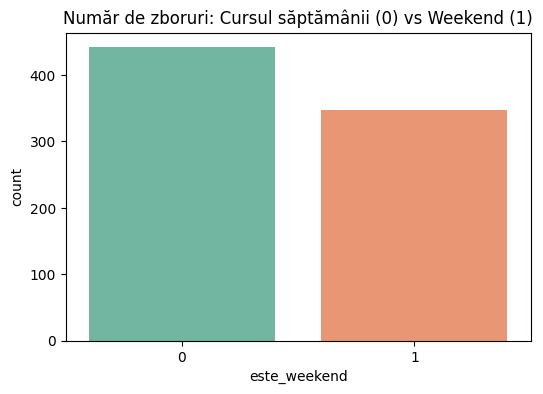

/tmp/ipykernel_1502/2179889333.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=test_df, x='numar_escale', palette='Pastel1')


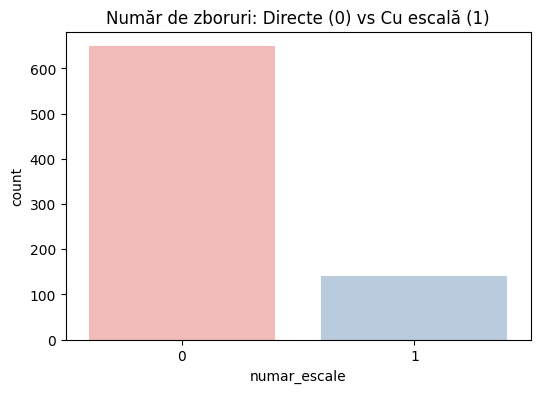

In [160]:
plt.figure(figsize=(6, 4))
sns.countplot(data=test_df, x='este_weekend', palette='Set2')
plt.title('Numar de zboruri: Cursul saptamanii (0) vs Weekend (1)')
plt.show()

plt.figure(figsize=(6, 4))
sns.countplot(data=test_df, x='numar_escale', palette='Pastel1')
plt.title('Numar de zboruri: Directe (0) vs Cu escala (1)')
plt.show()

**Ce observam?** Aceleasi coloane discrete dar din setul de test. Proportiile ar trebui sa fie similare cu cele din train.

**Suspiciuni/idei:** Daca in train avem 10% zboruri cu escale si in test avem 30%, ceva nu e in regula cu impartirea datelor. Un test bun trebuie sa "arate" la fel ca train-ul ca distributie.

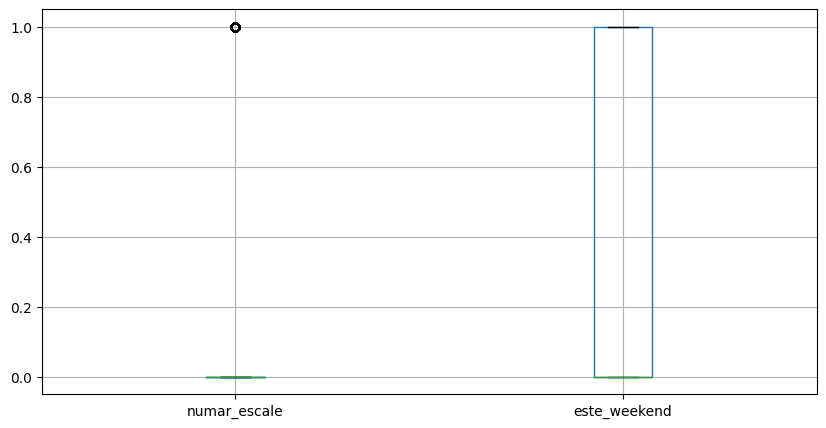

In [139]:
plt.figure(figsize=(10, 5))
countplot_train.boxplot()
plt.show()

**Ce observam?** Boxplot pentru variabilele discrete din train. Deoarece `numar_escale` ia valori mici (0, 1, 2) si `este_weekend` e binar (0 sau 1), cutiile vor fi foarte mici si inguste - nu e nimic "gresit", asa arata un boxplot pe date cu putine valori posibile.

**Suspiciuni/idei:** Mediana lui `numar_escale` e probabil 0, confirmand ca zborul direct e regula in dataset. Mediana lui `este_weekend` probabil e 0 sau 1, in functie de cat de multe zile de weekend sunt in intervalul 20 iunie - 23 august.

**Preprocesari necesare:** Nicio preprocesare suplimentara - variabilele sunt deja in format numeric potrivit pentru model.

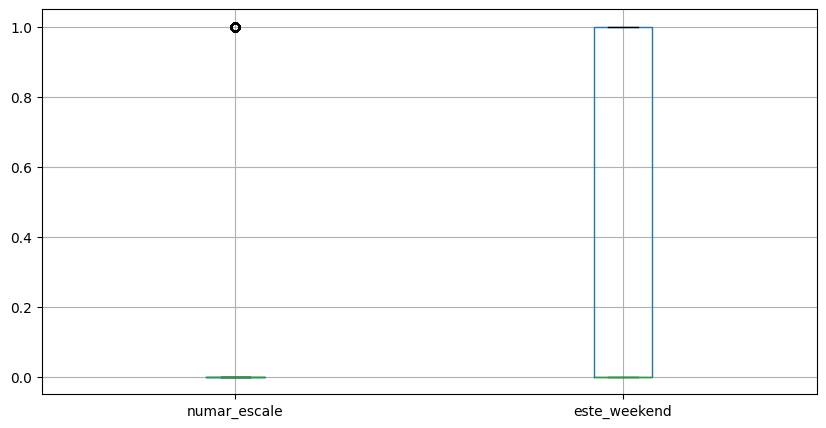

In [140]:
plt.figure(figsize=(10, 5))
countplot_test.boxplot()
plt.show()

**Ce observam?** Acelasi boxplot pentru setul de test. Il comparam vizual cu cel din train ca un ultim check de consistenta pentru variabilele discrete.

**Suspiciuni/idei:** Daca medianele si quartilele sunt similare intre train si test, suntem in regula. Nu ne asteptam la surprize daca countplot-urile anterioare erau ok.

**Preprocesari necesare:** Nicio preprocesare suplimentara.

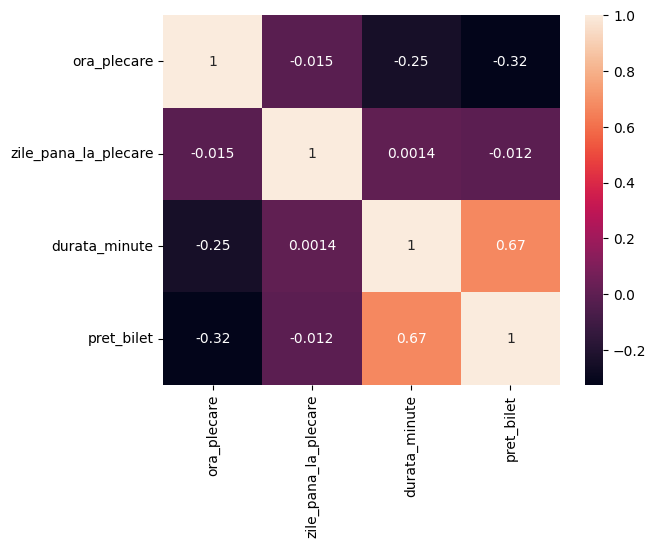

In [141]:
matrice = hist_train_df.corr()
sns.heatmap(matrice, annot=True)
plt.show()

**Ce observam?** Heatmap-ul de corelatie ne spune cat de mult se "misca impreuna" doua variabile. Valorile merg de la -1 la 1: 1 inseamna ca daca una creste, cealalta creste la fel, -1 inseamna ca daca una creste, cealalta scade, iar 0 inseamna ca nu au nicio relatie. Ne uitam in special la randul/coloana `pret_bilet` ca sa vedem ce variabile influenteaza pretul.



**Preprocesari necesare:** Daca doua variabile predictoare au corelatie de 0.95 sau mai mare intre ele, inseamna ca practic spun acelasi lucru si una ar putea fi eliminata.

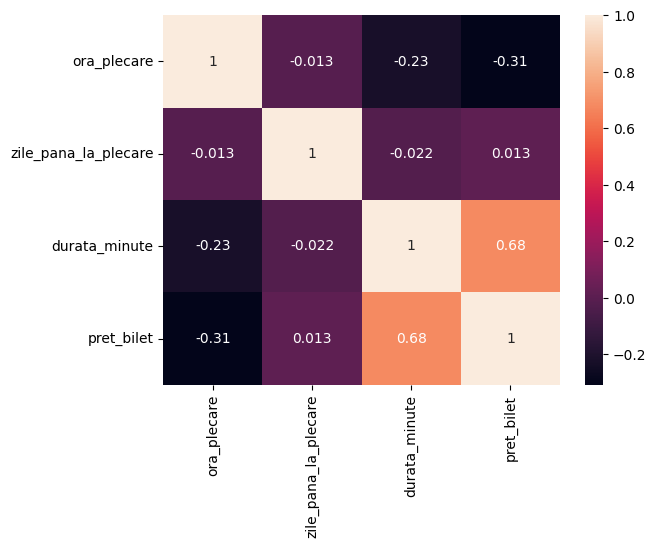

In [142]:
matrice2 = hist_test_df.corr()
sns.heatmap(matrice2, annot=True)
plt.show()

**Ce observam?** Aceeasi matrice de corelatie dar calculata pe setul de test. Valorile exacte vor fi putin diferite fata de train (pentru ca avem mai putine date), dar pattern-ul general ar trebui sa fie similar.

**Suspiciuni/idei:** Daca o corelatie care era 0.7 in train devine 0.1 in test, asta e ingrijorator - inseamna ca relatia dintre acele doua variabile nu e stabila si modelul s-ar putea sa nu generalizeze bine.

**Preprocesari necesare:** Nicio preprocesare suplimentara - matricea de corelatie e doar pentru analiza, nu modifica datele.

## Scatter plots - Setul de Train

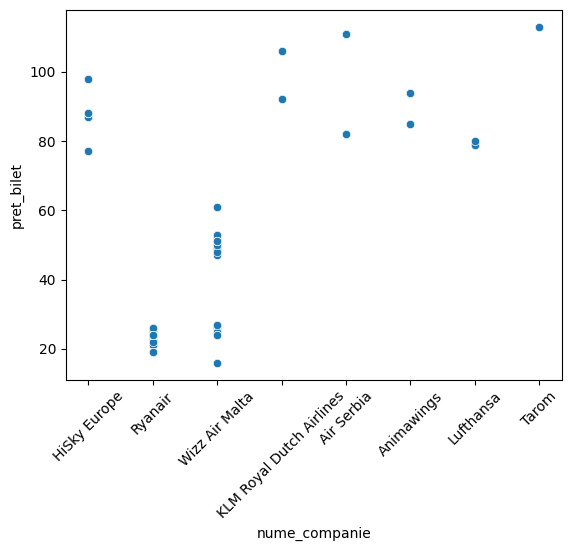

In [143]:
sns.scatterplot(data=train_df, x="nume_companie", y="pret_bilet")
plt.xticks(rotation=45)
plt.show()

**Ce observam?** Fiecare coloana verticala de puncte reprezinta o companie aeriana. Companiile low-cost (Wizz Air, Ryanair) ar trebui sa aiba punctele concentrate jos (preturi mici), in timp ce companiile mai mari (Lufthansa, British Airways) vor avea puncte si sus si jos, cu o medie mai ridicata.

**Suspiciuni/idei:** Daca o companie are un singur punct in tot graficul, inseamna ca am colectat un singur zbor de la ea. Asta e o problema pentru model - nu poate invata comportamentul de pret al unei companii dintr-un singur exemplu, cam cum nu poti judeca un profesor dupa o singura nota.

**Preprocesari necesare:** Companiile cu foarte putine aparitii ar putea fi grupate intr-o categorie "Other" pentru ca modelul sa nu "memoreze" acel unic exemplu.

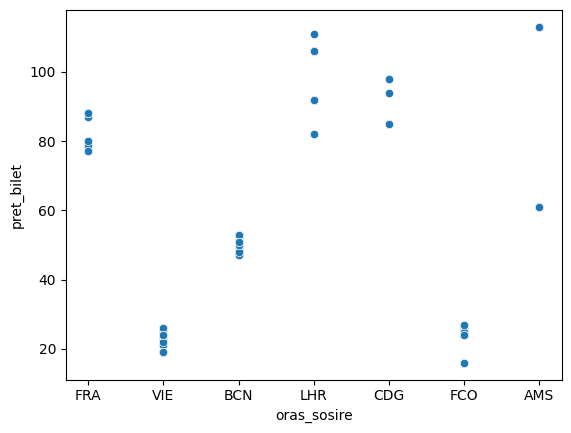

In [144]:
sns.scatterplot(data=train_df, x="oras_sosire", y="pret_bilet")
plt.show()

**Ce observam?** Pentru fiecare destinatie vedem intervalul de preturi al biletelor. Ne asteptam ca destinatiile mai indepartate (Londra, Amsterdam) sa aiba in general preturi mai mari si mai variabile, iar Viena sau Roma sa fie mai accesibile din Bucuresti avand in vedere distanta geografica.

**Suspiciuni/idei:** Daca Barcelona apare cu preturi mai mici decat Viena (desi e mai departe), probabil exista o concurenta mai mare pe acea ruta sau mai multe zboruri low-cost. Asta ar fi o observatie interesanta despre piata biletelor.

**Preprocesari necesare:** Destinatia e deja o coloana de text pe care o vom converti in numere prin One-Hot Encoding mai tarziu - adica fiecare oras devine o coloana separata de 0 si 1.

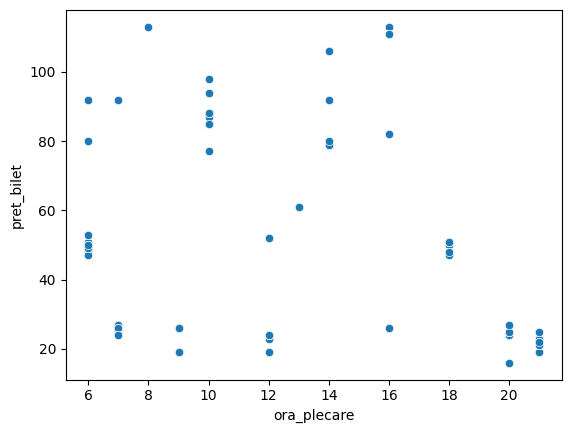

In [145]:
sns.scatterplot(data=train_df, x="ora_plecare", y="pret_bilet")
plt.show()

**Ce observam?** Pe axa X avem ora (0-23), pe axa Y pretul. Ne uitam daca exista ore la care biletele sunt in mod constant mai ieftine sau mai scumpe. De exemplu, zborurile la 6 dimineata sau la 23 noaptea sunt de obicei mai ieftine pentru ca putini oameni vor sa se trezeasca la 4 ca sa prinda zborul.

**Suspiciuni/idei:** Daca graficul arata un nor de puncte fara niciun pattern clar, inseamna ca ora singura nu determina pretul - e influentat mai mult de destinatie sau companie. Daca vedem preturi mai mici la ore extreme (noapte/dimineata devreme), asta confirma ce stim din experienta.

**Preprocesari necesare:** Ora e deja un numar intreg 0-23, deci modelul o poate folosi direct. Nu are nevoie de transformari.

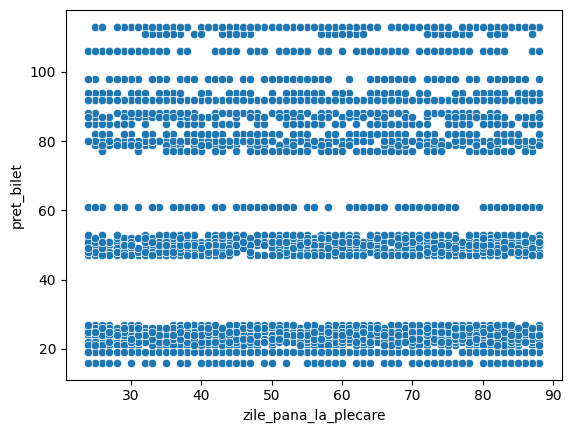

In [146]:
sns.scatterplot(data=train_df, x="zile_pana_la_plecare", y="pret_bilet")
plt.show()

**Ce observam?** Acesta e probabil cel mai interesant grafic din toata analiza. Pe axa X avem cu cate zile inainte ai rezervat biletul, pe axa Y pretul. Daca punctele sunt mai sus spre stanga (putine zile ramase = pret mare), confirma ceva pe care il stim cu totii: daca lasi pe ultima suta de metri, platesti mai mult.

**Suspiciuni/idei:** Pattern-ul ar putea sa nu fie o linie dreapta simpla - la rezervarile facute cu mult timp inainte pretul poate fi si el ridicat (companiile cer mai mult cand locurile sunt inca multe), scade la mijloc, apoi creste iar pe masura ce se umple avionul. Daca vedem asa ceva in grafic ar fi foarte interesant de mentionat.

**Preprocesari necesare:** Daca pattern-ul e in forma de U, o simpla linie dreapta nu il va captura bine. Am putea adauga o coloana noua cum ar fi "rezervare_tarzie" (1 daca mai sunt sub 7 zile, 0 altfel) pentru a ajuta modelul.

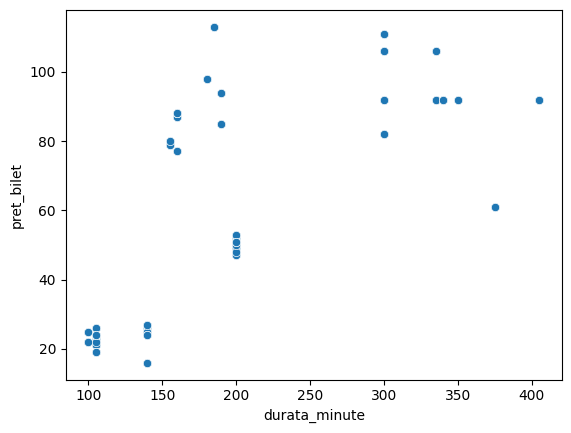

In [147]:
sns.scatterplot(data=train_df, x="durata_minute", y="pret_bilet")
plt.show()

**Ce observam?** Cu cat zborul dureaza mai mult, cu atat e mai scump - asta ne-am astepta sa vedem. Dar mai interesant, probabil vedem mai multe "grupuri" de puncte: un grup in jurul lui 100-150 minute (zboruri scurte spre Viena/Roma), un grup in jurul lui 300-400 minute (Londra/Amsterdam). Fiecare grup corespunde unei destinatii.

**Suspiciuni/idei:** Daca grupurile sunt clar separate pe axa X, inseamna ca `durata_minute` si `oras_sosire` ne spun cam acelasi lucru - zborul spre Viena dureaza mereu ~105 minute. Asta se numeste coliniaritate si e ceva ce am vazut si in heatmap.

**Preprocesari necesare:** Nu sunt necesare transformari. Durata e un predictor intuitiv si modelul o va folosi bine.

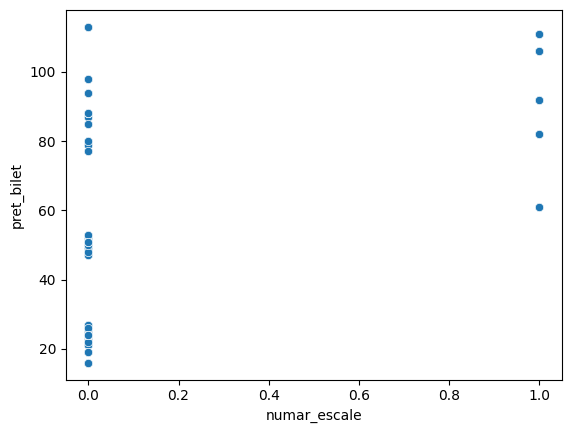

In [148]:
sns.scatterplot(data=train_df, x="numar_escale", y="pret_bilet")
plt.show()

**Ce observam?** Trei coloane verticale de puncte: una pentru 0 escale, una pentru 1 escala, una pentru 2 escale (daca exista). Coloana cu 0 escale e cu siguranta cea mai groasa (mai multe puncte) si are cea mai larga distributie de preturi. Coloanele cu escale au mai putine puncte.

**Suspiciuni/idei:** Contra-intuitiv, zborurile cu escale nu sunt neaparat mai ieftine - uneori sunt mai scumpe daca sunt singura optiune pe o ruta. Daca media preturilor creste cu numarul de escale, ar fi o observatie interesanta de mentionat in proiect.

**Preprocesari necesare:** `numar_escale` e deja un numar intreg mic (0, 1, 2), deci modelul il poate folosi direct.

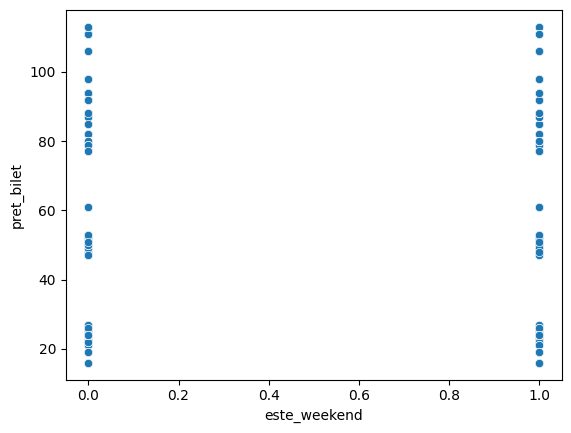

In [149]:
sns.scatterplot(data=train_df, x="este_weekend", y="pret_bilet")
plt.show()

**Ce observam?** Doar doua coloane de puncte: 0 (zboruri in timpul saptamanii) si 1 (zboruri de weekend). Ne uitam daca coloana de 1 e in general mai sus decat coloana de 0. Daca da, confirma ca zborurile de weekend sunt mai scumpe, ceea ce are sens: mai multi oameni vor sa zboare vineri seara sau sambata dimineata pentru un city break.

**Suspiciuni/idei:** Diferenta poate fi subtila si greu de vazut in scatter. Un boxplot pe aceasta variabila ar arata mai clar daca mediana preturilor de weekend e mai mare. Oricum, chiar daca diferenta e mica vizual, modelul o poate detecta in date.

**Preprocesari necesare:** Variabila e deja binara (0 sau 1), exact ce are nevoie modelul. Am creat-o noi din `zile_pana_la_plecare`, deci e un feature "engineered" - adica l-am construit noi, nu era direct in datele brute.

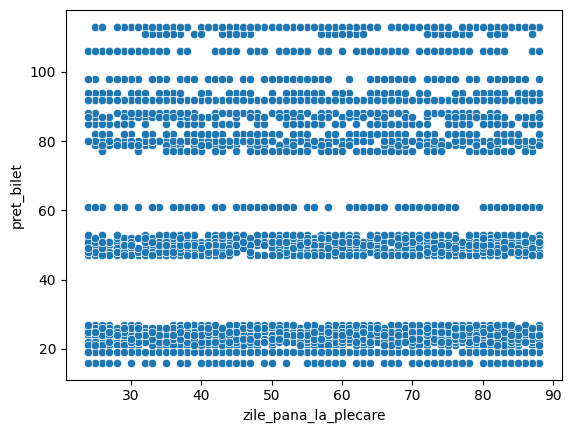

In [150]:
sns.scatterplot(data=train_df, x="zile_pana_la_plecare", y="pret_bilet")
plt.show()

**Ce observam?** Aceasta e a doua afisare a scatter-ului `zile_pana_la_plecare` vs `pret_bilet` - o confirmare vizuala ca pattern-ul observat prima data e consistent si nu a fost o intamplare.

**Suspiciuni/idei:** Daca graficul arata identic cu primul, suntem in regula. Datele sunt stabile.

**Preprocesari necesare:** Aceleasi ca la prima afisare.

## Scatter plots - Setul de Test

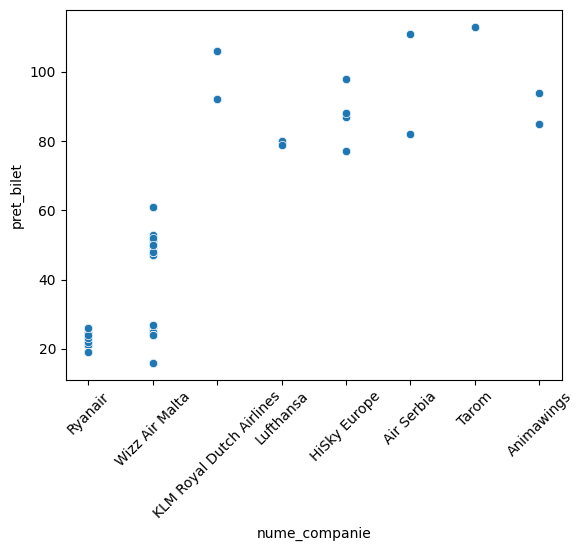

In [151]:
sns.scatterplot(data=test_df, x="nume_companie", y="pret_bilet")
plt.xticks(rotation=45)
plt.show()

**Ce observam?** Aceleasi companii ca in train, cu distributii similare de preturi. Verificam ca nu lipseste vreo companie din test sau ca nu apare una noua care nu era in train.

**Suspiciuni/idei:** Daca o companie apare in test dar nu in train, One-Hot Encoding-ul va genera o coloana noua pe care modelul nu a vazut-o niciodata. In codul nostru rezolvam asta cu `align` care umple coloanele lipsa cu 0, dar predictia pentru acea companie va fi mai slaba.

**Preprocesari necesare:** `align` rezolva problema tehnica, dar datele pentru companii rare raman nesigure.

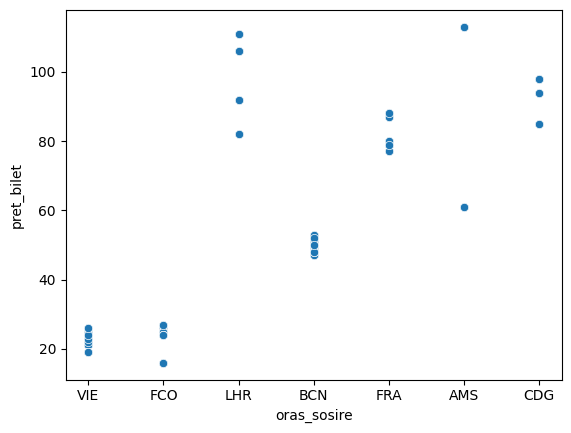

In [152]:
sns.scatterplot(data=test_df, x="oras_sosire", y="pret_bilet")
plt.show()

**Ce observam?** Toate cele 7 destinatii ar trebui sa fie prezente si in test. Verificam ca fiecare destinatie are suficiente puncte pentru o evaluare corecta a modelului.

**Suspiciuni/idei:** Daca Viena are 200 de zboruri in train si doar 5 in test, evaluarea modelului pentru Viena nu va fi reprezentativa. Modelul poate fi bun sau prost pe acea ruta si nu vom sti.

**Preprocesari necesare:** Nicio preprocesare suplimentara.

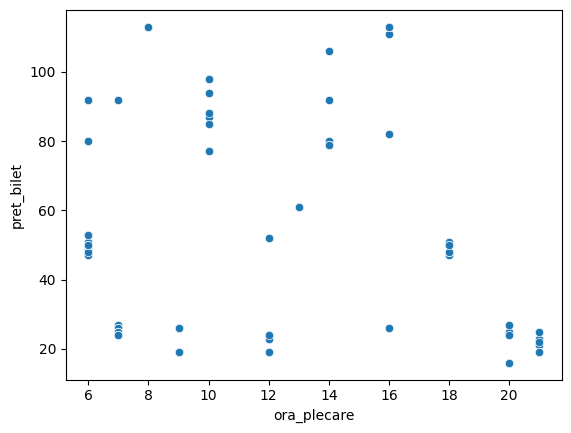

In [153]:
sns.scatterplot(data=test_df, x="ora_plecare", y="pret_bilet")
plt.show()

**Ce observam?** Distributia zborurilor pe ore in setul de test. Comparam cu train-ul sa vedem daca toate orele sunt acoperite si daca pattern-ul de preturi e similar.

**Suspiciuni/idei:** Daca in test nu avem deloc zboruri la ora 6 dimineata (dar in train avem), modelul nu va fi evaluat pe acel caz si nu stim cum se comporta acolo.

**Preprocesari necesare:** Nicio preprocesare suplimentara.

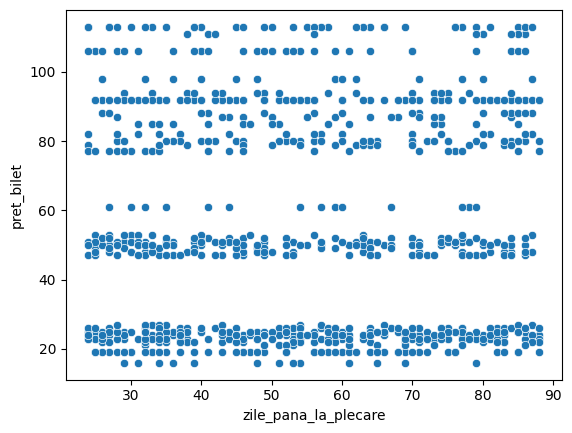

In [154]:
sns.scatterplot(data=test_df, x="zile_pana_la_plecare", y="pret_bilet")
plt.show()

**Ce observam?** Pattern-ul temporal din setul de test. Daca arata similar cu cel din train, inseamna ca impartirea datelor a pastrat bine varietatea rezervarilor facute din timp vs de ultim moment.

**Suspiciuni/idei:** Un split aleatoriu simplu (cum am folosit noi cu `random_state=42`) ar trebui sa distribuie uniform rezervarile timpurii si cele tarzii in ambele seturi. Daca nu e asa, inseamna ca `random_state`-ul ales a dat un split nefericit.

**Preprocesari necesare:** Nicio preprocesare suplimentara.

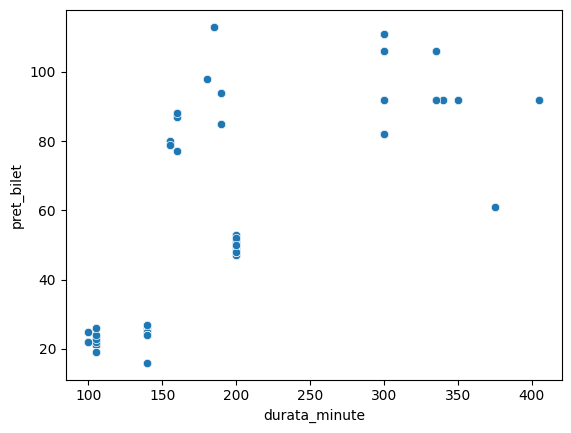

In [155]:
sns.scatterplot(data=test_df, x="durata_minute", y="pret_bilet")
plt.show()

**Ce observam?** Grupurile/clusterele pe destinatii ar trebui sa fie vizibile si in test, similare ca densitate cu cele din train. Fiecare grup de puncte corespunde unei destinatii la o anumita distanta.

**Suspiciuni/idei:** Daca un cluster e complet absent din test (de ex, nu avem niciun zbor scurt de ~100 minute), modelul nu va fi evaluat pe destinatiile scurte si nu stim cat de bine prezice pentru ele.

**Preprocesari necesare:** Nicio preprocesare suplimentara.

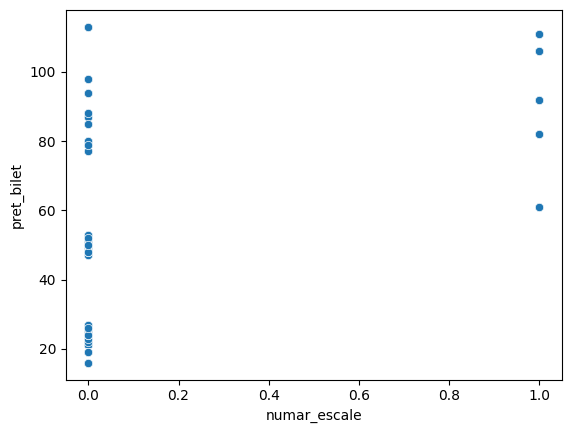

In [156]:
sns.scatterplot(data=test_df, x="numar_escale", y="pret_bilet")
plt.show()

**Ce observam?** Distributia zborurilor cu 0, 1 sau 2 escale in setul de test. Coloana cu 0 escale ar trebui sa fie in continuare dominanta, la fel ca in train.

**Suspiciuni/idei:** Daca in test avem proportional mai multe zboruri cu escale decat in train, erorile modelului vor fi mai mari la evaluare - nu pentru ca modelul e prost, ci pentru ca a fost testat mai mult pe cazuri pe care le-a vazut rar la antrenare.

**Preprocesari necesare:** Nicio preprocesare suplimentara.

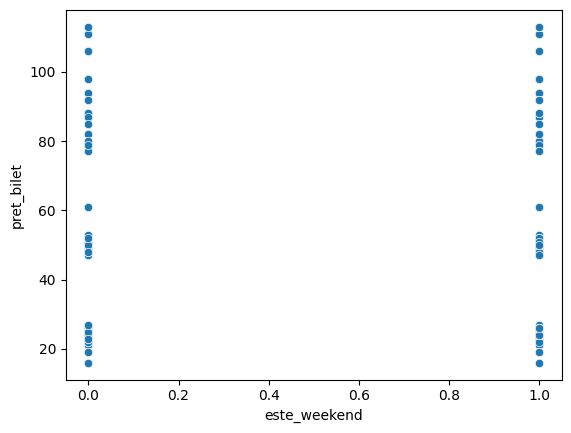

In [157]:
sns.scatterplot(data=test_df, x="este_weekend", y="pret_bilet")
plt.show()

**Ce observam?** Cele doua coloane de puncte (0 si 1) din setul de test. Diferenta de nivel intre ele ar trebui sa fie similara cu cea din train, confirmand ca efectul de weekend e consistent in toate datele, nu doar in cele de antrenare.

**Suspiciuni/idei:** Daca in test diferenta de pret intre weekend si non-weekend dispare, poate fi o coincidenta statistica (avem mai putine date in test) sau un semn ca efectul nu e la fel de puternic cum credeam.

**Preprocesari necesare:** Nicio preprocesare suplimentara - analiza exploratorie este completa si suntem gata sa trecem la antrenarea modelului.

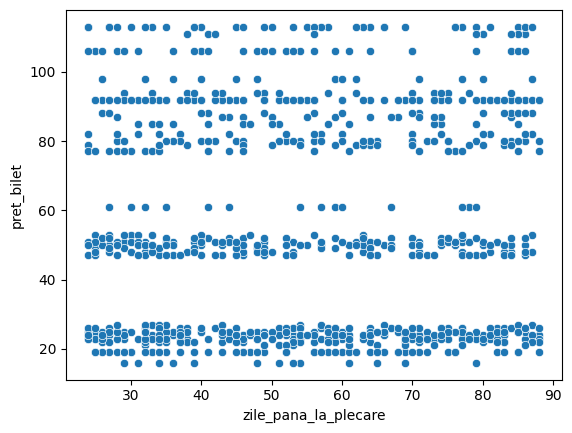

In [158]:
sns.scatterplot(data=test_df, x="zile_pana_la_plecare", y="pret_bilet")
plt.show()

**Ce observam?** Ultima confirmare vizuala - pattern-ul `zile_pana_la_plecare` vs pret in setul de test. Daca e consistent cu toate graficele anterioare, inseamna ca datele sunt curate, split-ul a mers bine si putem trece cu incredere la antrenarea modelului.

**Suspiciuni/idei:** La final de analiza exploratorie, concluzia generala e ca variabilele cele mai importante pentru pret vor fi probabil `oras_sosire`, `durata_minute` si `zile_pana_la_plecare`. Asta e o ipoteza pe care o vom putea verifica dupa antrenare uitandu-ne la "feature importance" din RandomForest.

**Preprocesari necesare:** Nicio preprocesare suplimentara. Datele sunt curate, valorile lipsa au fost completate, si suntem gata de modelare.